ДЗ:3, 4, 5


# Визуализация графов в NetworkX

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Макрушин С.В. "Лекция 1: Введение в сетевой анализ и знакомство с библиотекой NetworkX"
* Документация:
    * https://networkx.org/documentation/stable/reference/generated/networkx.generators.lattice.grid_2d_graph.html
    * https://networkx.org/documentation/stable/reference/drawing.html
    * https://networkx.org/documentation/stable/reference/generated/networkx.generators.social.karate_club_graph.html
    * https://networkx.org/documentation/stable/reference/generated/networkx.generators.social.les_miserables_graph.html
    * https://matplotlib.org/stable/users/explain/colors/colormaps.html
    * https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.colorbar.html
    

## Вопросы для совместного обсуждения

1\. Рассмотрите основные функции для визуализации графов в NetworkX и их возможности.

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Создайте двумерную решетку размера 5х3, используя готовую функцию из `networkx`. Создайте словарь `pos`, в котором ключами являются идентификаторы узлов, а значениями - координаты этих узлов на плоскости. Для получения координат узлов считайте, что идентификатор состоит из пар `(x, y)`, где `x` - позиция по _горизонтали_, а `y` - позиция по _вертикали_. Визуализируйте граф, используя полученный словарь. Добавьте на рисунок подписи узлов.

- [ ] Проверено на семинаре

<p class="task" id="2"></p>

2\. Создайте граф карате-клуба, используя готовую функцию из `networkx`. Используя функции вида `x_layout`, рассчитайте координаты узлов и визуализируйте различные укладки в виде сетки из изображений. Каждому изображению в сетке добавьте заголовок в виде названия используемой функции. Если какая-то функция укладки не применима к данному графу, игнорируйте ее.

- [ ] Проверено на семинаре

<p class="task" id="3"></p>

3\. Создайте граф карате-клуба, используя готовую функцию из `networkx`. Добавьте узлам атрибут `age`, заполненный целыми числами от 20 до 50. Визуализируйте граф, раскрасив узлы в цвет клуба (красный для "Mr. Hi" и зеленый для "Officer") и сделав размер узла пропорциональным величине атрибута `age`.

- [ ] Проверено на семинаре

In [14]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np

In [2]:
G = nx.karate_club_graph()

In [3]:
for node in G.nodes():
    G.nodes[node]['age'] = random.randint(20, 50)

In [4]:
color_map = []
for node in G.nodes():
    club = G.nodes[node]['club']
    color_map.append('red' if club == 'Mr. Hi' else 'green')

In [5]:
node_sizes = [G.nodes[node]['age'] * 10 for node in G.nodes()]  # Умножаем для лучшей видимости

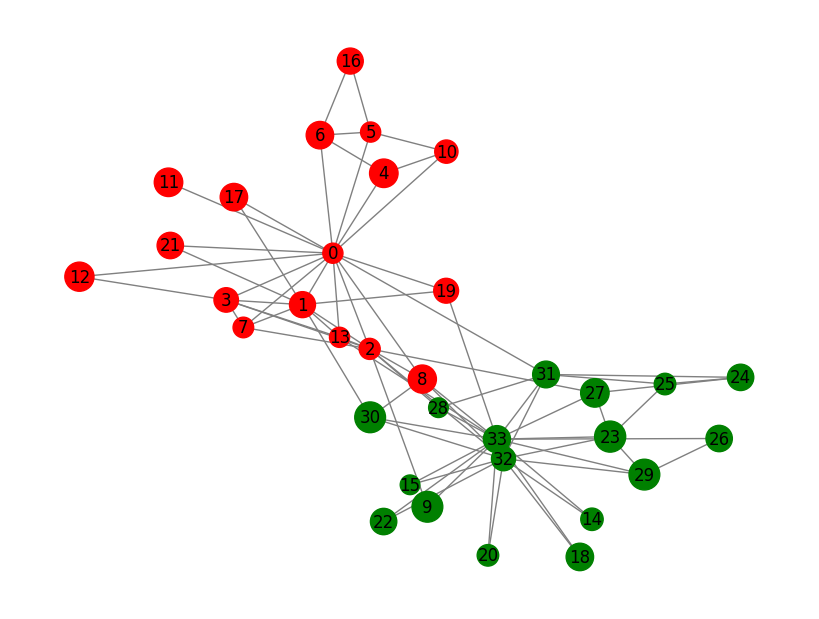

In [6]:
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)  # Фиксируем расположение для стабильности
nx.draw(G, pos, with_labels=True, node_color=color_map, node_size=node_sizes, edge_color='gray')

<p class="task" id="4"></p>

4\. Создайте ориентированный граф "путь" из 3 узлов. Визуализируйте граф со стрелками увеличенного размера. Визуализируйте граф, развернув стрелки в обратном направлении. На всех визуализациях добавляйте подписи узлов.

- [ ] Проверено на семинаре

In [9]:
# Создаем ориентированный граф "путь" из 3 узлов
G = nx.DiGraph()
G.add_edges_from([(1, 2), (2, 3)])

In [10]:
pos = nx.spring_layout(G, seed=42)  # Фиксируем расположение для стабильности

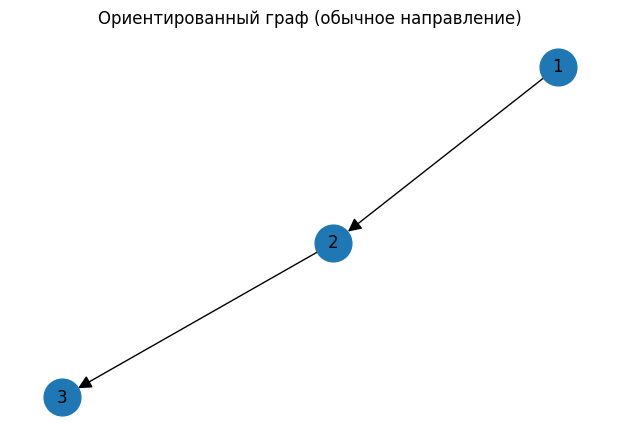

In [11]:
plt.figure(figsize=(6, 4))
nx.draw(G, pos, with_labels=True, arrows=True, arrowstyle='-|>', arrowsize=20, node_size=700, edge_color='black')
plt.title("Ориентированный граф (обычное направление)")
plt.show()

In [12]:
# Создаем граф с обратным направлением
G_reverse = G.reverse()

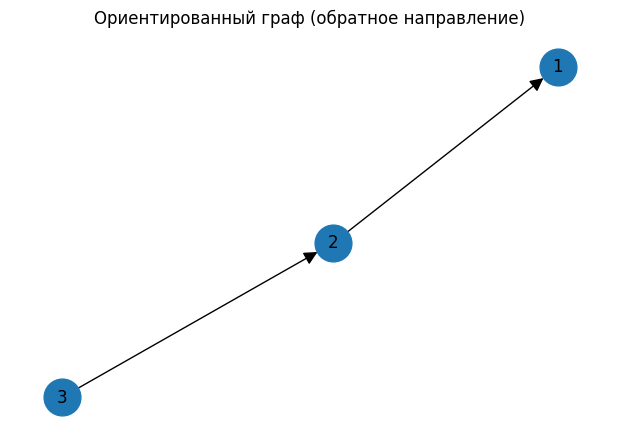

In [13]:
plt.figure(figsize=(6, 4))
nx.draw(G_reverse, pos, with_labels=True, arrows=True, arrowstyle='-|>', arrowsize=20, node_size=700, edge_color='black')
plt.title("Ориентированный граф (обратное направление)")
plt.show()

<p class="task" id="5"></p>

5\. Создайте граф `Les Miserables`. Для каждого узла зафиксируйте координату на плоскости при помощи функции `random_layout`. Отрисуйте узлы графа при помощи функции `draw_networkx_nodes` с указанием размера узлов 10. Получите список `edge_colors` значений атрибута `weight` на ребрах и ограничьте (clip) его сверху значением 10, снизу значением 1. Отрисуйте ребра графа при помощи функции `draw_networkx_edges`, раскрасив ребра в цвет, соответствующий значениям `edge_colors` с применением цветовой карты `viridis`. Добавьте на визуализацию colorbar, показывающий градиент цветов ребер.

- [ ] Проверено на семинаре

In [15]:
G = nx.les_miserables_graph()

# Фиксируем случайные координаты для узлов
pos = nx.random_layout(G, seed=42)

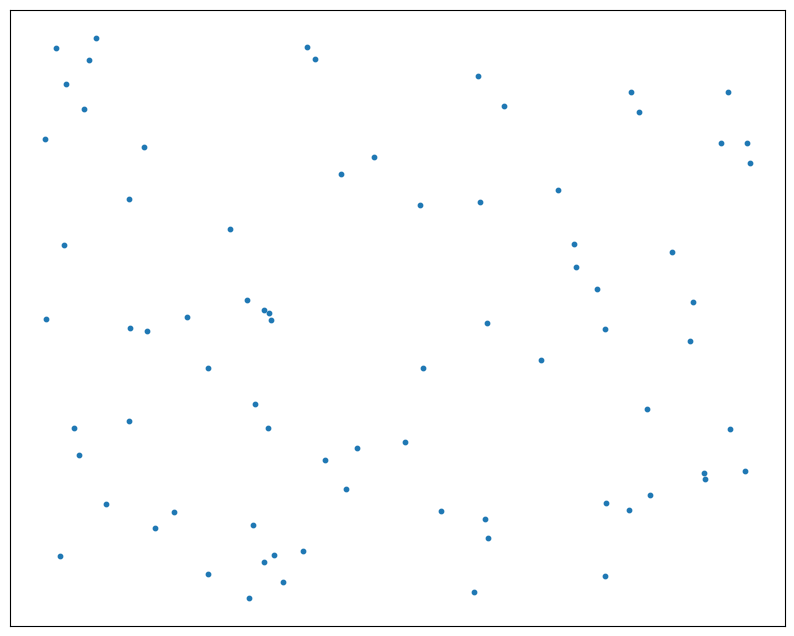

In [16]:
plt.figure(figsize=(10, 8))
nx.draw_networkx_nodes(G, pos, node_size=10)

In [17]:
weights = np.array([d['weight'] for _, _, d in G.edges(data=True)])
clipped_weights = np.clip(weights, 1, 10)

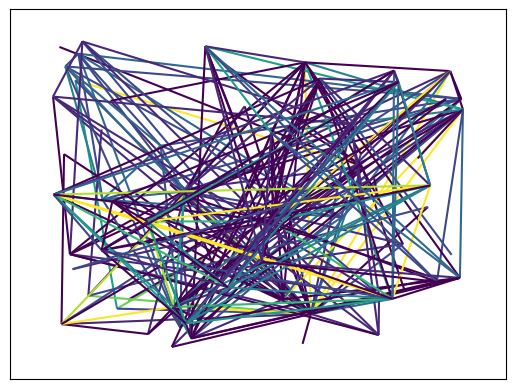

In [18]:
edges = nx.draw_networkx_edges(G, pos, edge_color=clipped_weights, edge_cmap=plt.cm.viridis, width=1.5)
